<a href="https://colab.research.google.com/github/Unnati0424/Incident-Tracker-Mini-App4/blob/main/FUTURE_ML_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Style
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('✅ All libraries imported successfully!')
print(f'   pandas {pd.__version__} | numpy {np.__version__}')

✅ All libraries imported successfully!
   pandas 2.2.2 | numpy 2.0.2


In [2]:
# ── Simulate 3 years of daily sales (2022–2024) ──────────────────────────────
np.random.seed(42)

date_range = pd.date_range(start='2022-01-01', end='2024-12-31', freq='D')
n = len(date_range)

# Seasonal pattern: Q4 high, Jan–Feb low
seasonal_map = {1:0.72, 2:0.78, 3:0.95, 4:1.02, 5:1.05, 6:1.08,
                7:1.03, 8:1.00, 9:1.10, 10:1.28, 11:1.45, 12:1.62}

base_daily = 600  # base daily sales in $
growth_rate = 0.00025  # daily trend growth

sales = []
for i, date in enumerate(date_range):
    trend = base_daily * (1 + i * growth_rate)
    season = seasonal_map[date.month]
    # Weekend dip
    dow_factor = 0.75 if date.weekday() >= 5 else 1.0
    noise = np.random.normal(0, 80)
    sales.append(max(0, round(trend * season * dow_factor + noise, 2)))

# Categories (proportional split)
categories = np.random.choice(
    ['Technology', 'Furniture', 'Office Supplies'],
    size=n,
    p=[0.48, 0.30, 0.22]
)

regions = np.random.choice(
    ['West', 'East', 'Central', 'South'],
    size=n, p=[0.32, 0.30, 0.22, 0.16]
)

df = pd.DataFrame({
    'Order Date': date_range,
    'Sales': sales,
    'Category': categories,
    'Region': regions
})

# ── If using real Superstore CSV, use this instead ────────────────────────────
# df = pd.read_csv('superstore.csv', parse_dates=['Order Date'])
# df = df[['Order Date', 'Sales', 'Category', 'Region']]

print(f'Dataset shape: {df.shape}')
print(f'Date range:    {df["Order Date"].min().date()} → {df["Order Date"].max().date()}')
print(f'Total Revenue: ${df["Sales"].sum():,.0f}')
df.head(10)

Dataset shape: (1096, 4)
Date range:    2022-01-01 → 2024-12-31
Total Revenue: $763,873


,Order Date,Sales,Category,Region
0,2022-01-01,363.74,Technology,West
1,2022-01-02,313.02,Furniture,East
2,2022-01-03,484.03,Technology,Central
3,2022-01-04,554.17,Technology,Central
4,2022-01-05,413.70,Office Supplies,Central
5,2022-01-06,413.81,Office Supplies,West
6,2022-01-07,558.99,Technology,West
7,2022-01-08,385.96,Office Supplies,East
8,2022-01-09,287.09,Furniture,Central
9,2022-01-10,476.38,Office Supplies,West


In [3]:
print('=== DATA QUALITY CHECK ===')
print(f'Total rows:      {len(df):,}')
print(f'Missing values:\n{df.isnull().sum()}')
print(f'Negative sales:  {(df["Sales"] < 0).sum()}')
print(f'Duplicate rows:  {df.duplicated().sum()}')

# Remove negatives & duplicates
df = df[df['Sales'] > 0].drop_duplicates().reset_index(drop=True)

# Fill any missing dates with 0 (sparse days)
df = df.set_index('Order Date').resample('D').sum(numeric_only=True).reset_index()

print(f'\n✅ After cleaning: {len(df):,} rows')

=== DATA QUALITY CHECK ===
Total rows:      1,096
Missing values:
Order Date    0
Sales         0
Category      0
Region        0
dtype: int64
Negative sales:  0
Duplicate rows:  0

✅ After cleaning: 1,096 rows


In [4]:
# Aggregate to MONTHLY for forecasting
monthly = df.resample('MS', on='Order Date').sum(numeric_only=True).reset_index()
monthly.columns = ['Date', 'Sales']

# ── Time-based features ────────────────────────────────────────────────────
monthly['Year']          = monthly['Date'].dt.year
monthly['Month']         = monthly['Date'].dt.month
monthly['Month_Name']    = monthly['Date'].dt.strftime('%b')
monthly['Quarter']       = monthly['Date'].dt.quarter
monthly['Time_Index']    = np.arange(len(monthly))          # linear time index
monthly['Is_Q4']         = (monthly['Quarter'] == 4).astype(int)
monthly['Is_Summer']     = monthly['Month'].isin([6,7,8]).astype(int)

# ── Seasonality dummies (one-hot encode months) ───────────────────────────
month_dummies = pd.get_dummies(monthly['Month'], prefix='M', drop_first=True)
monthly = pd.concat([monthly, month_dummies], axis=1)

# ── Lag features ──────────────────────────────────────────────────────────
monthly['Lag_1']  = monthly['Sales'].shift(1)   # last month
monthly['Lag_12'] = monthly['Sales'].shift(12)  # same month last year
monthly['Rolling_3M_Avg'] = monthly['Sales'].rolling(3).mean()

# Drop rows with NaN from lag
monthly_model = monthly.dropna().reset_index(drop=True)

print(f'Monthly records for modeling: {len(monthly_model)}')
print(f'Features created: {list(monthly_model.columns)}')
monthly_model[['Date','Sales','Month','Quarter','Time_Index','Lag_1','Rolling_3M_Avg']].tail(8)

Monthly records for modeling: 24
Features created: ['Date', 'Sales', 'Year', 'Month', 'Month_Name', 'Quarter', 'Time_Index', 'Is_Q4', 'Is_Summer', 'M_2', 'M_3', 'M_4', 'M_5', 'M_6', 'M_7', 'M_8', 'M_9', 'M_10', 'M_11', 'M_12', 'Lag_1', 'Lag_12', 'Rolling_3M_Avg']


,Date,Sales,Month,Quarter,Time_Index,Lag_1,Rolling_3M_Avg
16,2024-05-01,22740.55,5,2,28,21010.14,21143.503333
17,2024-06-01,22981.69,6,2,29,22740.55,22244.126667
18,2024-07-01,22095.00,7,3,30,22981.69,22605.746667
19,2024-08-01,21807.75,8,3,31,22095.00,22294.813333
20,2024-09-01,22466.27,9,3,32,21807.75,22123.006667
21,2024-10-01,28710.35,10,4,33,22466.27,24328.123333
22,2024-11-01,30689.75,11,4,34,28710.35,27288.790000
23,2024-12-01,35707.98,12,4,35,30689.75,31702.693333


In [5]:
# Feature columns
feature_cols = (['Time_Index', 'Quarter', 'Is_Q4', 'Is_Summer',
                 'Lag_1', 'Lag_12', 'Rolling_3M_Avg'] +
                [c for c in monthly_model.columns if c.startswith('M_')])

X = monthly_model[feature_cols].values
y = monthly_model['Sales'].values

# ── Train/Test split (last 6 months = test) ───────────────────────────────
SPLIT = -6
X_train, X_test = X[:SPLIT], X[SPLIT:]
y_train, y_test = y[:SPLIT], y[SPLIT:]

print(f'Training samples: {len(X_train)} months')
print(f'Test samples:     {len(X_test)} months')

# ── Scale features ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Fit Linear Regression ─────────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train_sc, y_train)

# ── Predictions ───────────────────────────────────────────────────────────
y_pred_train = model.predict(X_train_sc)
y_pred_test  = model.predict(X_test_sc)

print('\n✅ Model trained successfully!')

Training samples: 18 months
Test samples:     6 months

✅ Model trained successfully!


In [6]:
def mape(actual, predicted):
    """Mean Absolute Percentage Error"""
    return np.mean(np.abs((actual - predicted) / actual)) * 100

mae_val  = mean_absolute_error(y_test, y_pred_test)
rmse_val = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_val   = r2_score(y_test, y_pred_test)
mape_val = mape(y_test, y_pred_test)

print('='*45)
print('   MODEL PERFORMANCE — TEST SET (6 months)')
print('='*45)
print(f'  R² Score  :  {r2_val:.4f}   (closer to 1 = better)')
print(f'  MAE       :  ${mae_val:,.0f}')
print(f'  RMSE      :  ${rmse_val:,.0f}')
print(f'  MAPE      :  {mape_val:.2f}%')
print('='*45)

if mape_val < 15:
    print('  ✅ Good forecast accuracy (MAPE < 15%)')
elif mape_val < 25:
    print('  ⚠️  Reasonable accuracy (MAPE 15–25%)')
else:
    print('  ❌ High error — consider adding more features')


   MODEL PERFORMANCE — TEST SET (6 months)
  R² Score  :  0.9865   (closer to 1 = better)
  MAE       :  $545
  RMSE      :  $608
  MAPE      :  2.13%
  ✅ Good forecast accuracy (MAPE < 15%)


In [7]:
last_row    = monthly_model.iloc[-1]
last_date   = monthly_model['Date'].iloc[-1]
last_ti     = monthly_model['Time_Index'].iloc[-1]
last_sales  = monthly_model['Sales'].iloc[-1]
lag12_vals  = monthly_model['Sales'].values

FORECAST_MONTHS = 6
forecast_dates  = pd.date_range(start=last_date + pd.DateOffset(months=1),
                                periods=FORECAST_MONTHS, freq='MS')

forecast_sales  = []
prev_sales      = last_sales
roll_window     = list(monthly_model['Sales'].values[-3:])

for i, fd in enumerate(forecast_dates):
    ti      = last_ti + i + 1
    month   = fd.month
    quarter = fd.quarter
    is_q4   = int(quarter == 4)
    is_sum  = int(month in [6,7,8])
    lag1    = prev_sales
    lag12   = lag12_vals[-(12 - i)] if i < 12 else lag12_vals[i - 12]
    roll3   = np.mean(roll_window[-3:])

    # Month dummies (M_2 … M_12)
    m_dums = [int(month == m) for m in range(2, 13)]

    row = np.array([[ti, quarter, is_q4, is_sum, lag1, lag12, roll3] + m_dums])
    row_sc = scaler.transform(row)
    pred   = max(0, model.predict(row_sc)[0])

    forecast_sales.append(pred)
    roll_window.append(pred)
    prev_sales = pred

forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Forecast': np.round(forecast_sales, 2)
})

# Confidence interval ±(5% + 2% per month out)
forecast_df['CI_Low']  = forecast_df['Forecast'] * [1 - (0.05 + 0.02*i) for i in range(6)]
forecast_df['CI_High'] = forecast_df['Forecast'] * [1 + (0.05 + 0.02*i) for i in range(6)]
forecast_df = forecast_df.round(2)

print('6-MONTH SALES FORECAST')
print('='*55)
for _, row in forecast_df.iterrows():
    print(f"  {row['Date'].strftime('%b %Y')}:  "
          f"${row['Forecast']:>10,.0f}   "
          f"[${row['CI_Low']:>9,.0f} – ${row['CI_High']:>10,.0f}]")
print('='*55)
print(f"  TOTAL FORECAST 6-MO: ${forecast_df['Forecast'].sum():,.0f}")

6-MONTH SALES FORECAST
  Jan 2025:  $    23,316   [$   22,150 – $    24,482]
  Feb 2025:  $    24,750   [$   23,018 – $    26,483]
  Mar 2025:  $    31,764   [$   28,905 – $    34,623]
  Apr 2025:  $    26,364   [$   23,464 – $    29,264]
  May 2025:  $    29,230   [$   25,430 – $    33,030]
  Jun 2025:  $    29,401   [$   24,991 – $    33,811]
  TOTAL FORECAST 6-MO: $164,825


In [8]:
# Monthly seasonality index
monthly_avg = monthly.groupby('Month')['Sales'].mean()
overall_avg = monthly['Sales'].mean()
season_idx  = (monthly_avg / overall_avg * 100).round(1)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
print('MONTHLY SEASONALITY INDEX (avg = 100)')
print('-'*40)
for m, idx in zip(month_labels, season_idx.values):
    bar = '█' * int(idx / 10)
    flag = '🔥' if idx >= 140 else ('❄️' if idx <= 80 else '  ')
    print(f'  {m:3s}: {idx:5.1f}  {bar} {flag}')

MONTHLY SEASONALITY INDEX (avg = 100)
----------------------------------------
  Jan:  63.5  ██████ ❄️
  Feb:  65.1  ██████ ❄️
  Mar:  85.6  ████████   
  Apr:  89.6  ████████   
  May:  96.7  █████████   
  Jun:  97.8  █████████   
  Jul:  95.6  █████████   
  Aug:  95.0  █████████   
  Sep:  99.7  █████████   
  Oct: 121.9  ████████████   
  Nov: 135.3  █████████████   
  Dec: 154.3  ███████████████ 🔥


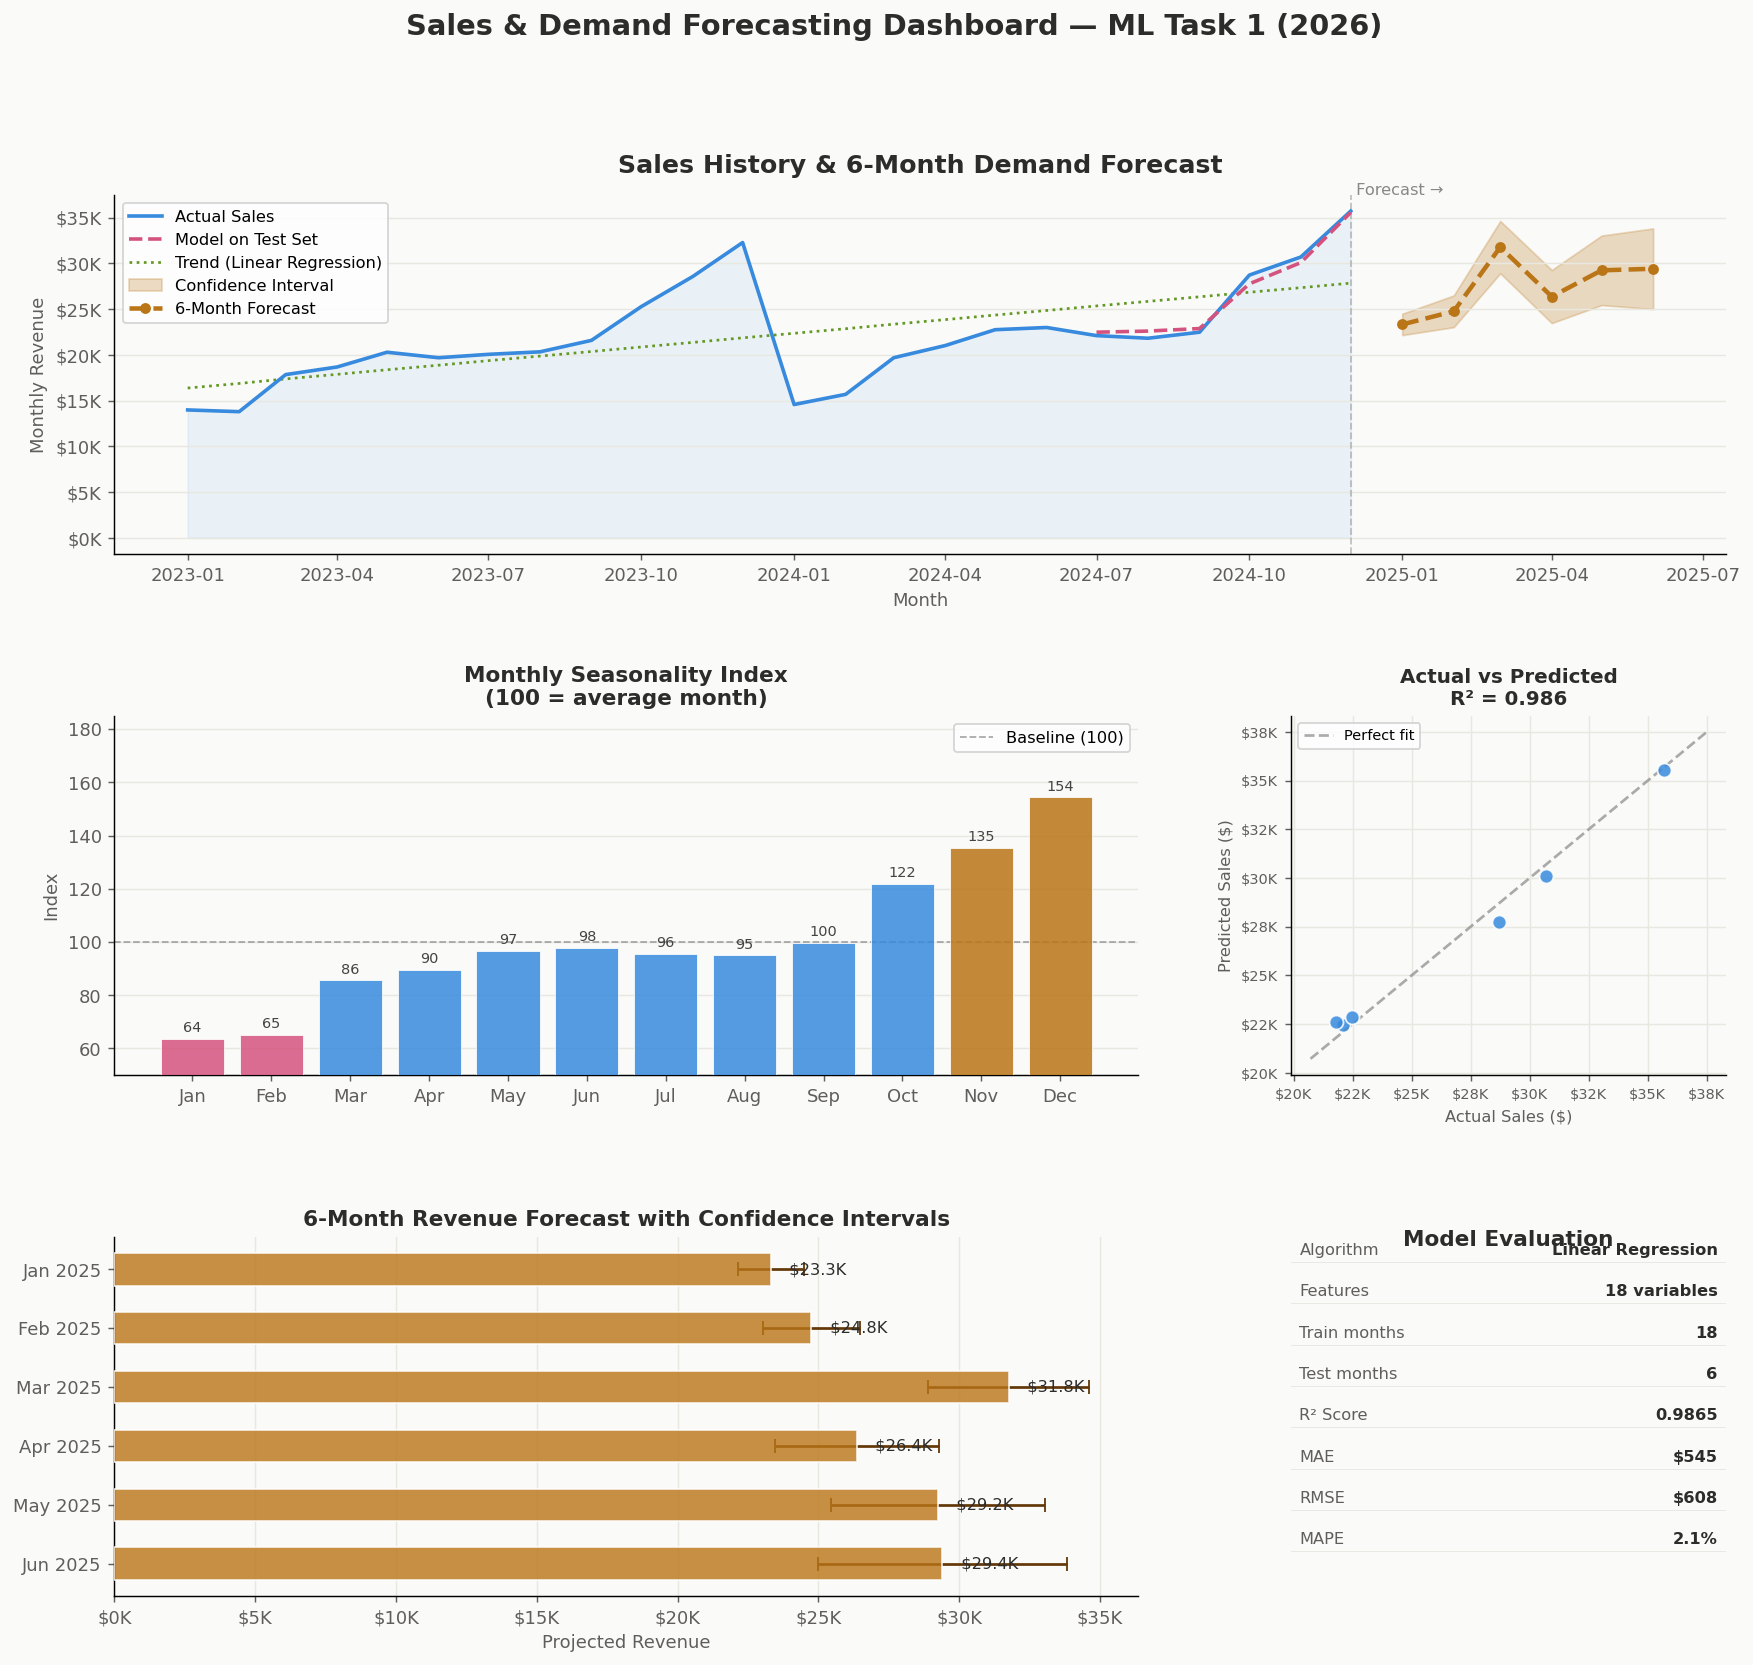


✅ Dashboard saved as sales_forecast_dashboard.png


In [11]:
# ── Color palette ─────────────────────────────────────────────────────────
COL_ACTUAL   = '#378ADD'
COL_TREND    = '#639922'
COL_FORECAST = '#BA7517'
COL_CI       = '#FAEEDA'
COL_TEST     = '#D4537E'
COL_BG       = '#FAFAF9'
COL_GRID     = '#E8E7E0'

fig = plt.figure(figsize=(16, 14))
fig.patch.set_facecolor(COL_BG)
gs  = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ─────────────────────────────────────────────────────────────────────────
# CHART 1 — Main Forecast Chart (full width)
# ─────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(COL_BG)
ax1.grid(axis='y', color=COL_GRID, linewidth=0.8)

# Historical actuals
hist_dates  = monthly_model['Date']
hist_sales  = monthly_model['Sales']
ax1.plot(hist_dates, hist_sales, color=COL_ACTUAL, linewidth=2,
         label='Actual Sales', zorder=3)
ax1.fill_between(hist_dates, hist_sales, alpha=0.08, color=COL_ACTUAL)

# Train predictions overlay
train_dates = monthly_model['Date'].iloc[:SPLIT]
test_dates  = monthly_model['Date'].iloc[SPLIT:]
ax1.plot(test_dates, y_pred_test, color=COL_TEST, linewidth=2,
         linestyle='--', label='Model on Test Set', zorder=4)

# Trend line (simple linear)
ti_arr  = monthly_model['Time_Index'].values.reshape(-1, 1)
lr_base = LinearRegression().fit(ti_arr, hist_sales)
trend_y = lr_base.predict(ti_arr)
ax1.plot(hist_dates, trend_y, color=COL_TREND, linewidth=1.5,
         linestyle=':', label='Trend (Linear Regression)', zorder=2)

# Forecast
ax1.fill_between(forecast_df['Date'],
                 forecast_df['CI_Low'], forecast_df['CI_High'],
                 alpha=0.25, color=COL_FORECAST, label='Confidence Interval')
ax1.plot(forecast_df['Date'], forecast_df['Forecast'],
         color=COL_FORECAST, linewidth=2.5, linestyle='--',
         marker='o', markersize=5, label='6-Month Forecast', zorder=5)

# Divider line
ax1.axvline(last_date, color='#888', linewidth=1, linestyle='--', alpha=0.5)
ax1.text(last_date, ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 1,
         ' Forecast →', fontsize=9, color='#888')

ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax1.set_title('Sales History & 6-Month Demand Forecast', fontsize=14,
              fontweight='bold', pad=12, color='#2C2C2A')
ax1.set_xlabel('Month', fontsize=10, color='#5F5E5A')
ax1.set_ylabel('Monthly Revenue', fontsize=10, color='#5F5E5A')
ax1.legend(loc='upper left', fontsize=9, framealpha=0.8)
ax1.tick_params(colors='#5F5E5A')

# ─────────────────────────────────────────────────────────────────────────
# CHART 2 — Seasonality Index
# ─────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :2])
ax2.set_facecolor(COL_BG)
ax2.grid(axis='y', color=COL_GRID, linewidth=0.8)

bar_colors = [COL_FORECAST if v >= 128 else (COL_TEST if v <= 85 else COL_ACTUAL)
              for v in season_idx.values]
bars = ax2.bar(month_labels, season_idx.values, color=bar_colors,
               alpha=0.85, edgecolor='white', linewidth=0.5, zorder=3)
ax2.axhline(100, color='#888', linewidth=1, linestyle='--', alpha=0.7, label='Baseline (100)')
for bar, val in zip(bars, season_idx.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.0f}', ha='center', va='bottom', fontsize=8, color='#444')
ax2.set_title('Monthly Seasonality Index\n(100 = average month)',
              fontsize=12, fontweight='bold', color='#2C2C2A')
ax2.set_ylabel('Index', fontsize=10, color='#5F5E5A')
ax2.set_ylim(50, 185)
ax2.tick_params(colors='#5F5E5A')
ax2.legend(fontsize=9)

# ─────────────────────────────────────────────────────────────────────────
# CHART 3 — Actual vs Predicted (Test Set)
# ─────────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
ax3.set_facecolor(COL_BG)
ax3.grid(color=COL_GRID, linewidth=0.8)

ax3.scatter(y_test, y_pred_test, color=COL_ACTUAL, alpha=0.85,
            edgecolors='white', s=60, zorder=3)
lims = [min(y_test.min(), y_pred_test.min()) * 0.95,
        max(y_test.max(), y_pred_test.max()) * 1.05]
ax3.plot(lims, lims, '--', color='#888', linewidth=1.5, alpha=0.7, label='Perfect fit')
ax3.set_xlabel('Actual Sales ($)', fontsize=9, color='#5F5E5A')
ax3.set_ylabel('Predicted Sales ($)', fontsize=9, color='#5F5E5A')
ax3.set_title(f'Actual vs Predicted\nR² = {r2_val:.3f}',
              fontsize=11, fontweight='bold', color='#2C2C2A')
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax3.tick_params(colors='#5F5E5A', labelsize=8)
ax3.legend(fontsize=8)

# ─────────────────────────────────────────────────────────────────────────
# CHART 4 — Forecast Table as Bar Chart
# ─────────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, :2])
ax4.set_facecolor(COL_BG)
ax4.grid(axis='x', color=COL_GRID, linewidth=0.8)

fc_labels = forecast_df['Date'].dt.strftime('%b %Y').values
fc_vals   = forecast_df['Forecast'].values
fc_low    = forecast_df['CI_Low'].values
fc_high   = forecast_df['CI_High'].values

bars4 = ax4.barh(fc_labels, fc_vals, color=COL_FORECAST, alpha=0.8,
                 edgecolor='white', height=0.55, zorder=3)
ax4.errorbar(fc_vals, fc_labels,
             xerr=[fc_vals - fc_low, fc_high - fc_vals],
             fmt='none', color='#633806', capsize=4, linewidth=1.5)
for bar, val in zip(bars4, fc_vals):
    ax4.text(val + 300, bar.get_y() + bar.get_height()/2,
             f'  ${val/1000:.1f}K', va='center', fontsize=9, color='#2C2C2A')
ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax4.set_title('6-Month Revenue Forecast with Confidence Intervals',
              fontsize=12, fontweight='bold', color='#2C2C2A')
ax4.set_xlabel('Projected Revenue', fontsize=10, color='#5F5E5A')
ax4.tick_params(colors='#5F5E5A')
ax4.invert_yaxis()

# ─────────────────────────────────────────────────────────────────────────
# CHART 5 — Model Metrics Summary
# ─────────────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 2])
ax5.set_facecolor(COL_BG)
ax5.axis('off')

metrics = [
    ('Algorithm', 'Linear Regression'),
    ('Features', f'{len(feature_cols)} variables'),
    ('Train months', str(len(X_train))),
    ('Test months', str(len(X_test))),
    ('R² Score', f'{r2_val:.4f}'),
    ('MAE', f'${mae_val:,.0f}'),
    ('RMSE', f'${rmse_val:,.0f}'),
    ('MAPE', f'{mape_val:.1f}%'),
]
y_pos = 0.95
ax5.text(0.5, 1.02, 'Model Evaluation', ha='center', va='top',
         fontsize=12, fontweight='bold', color='#2C2C2A',
         transform=ax5.transAxes)
for label, val in metrics:
    ax5.text(0.02, y_pos, label, fontsize=9, color='#5F5E5A',
             transform=ax5.transAxes)
    ax5.text(0.98, y_pos, val, fontsize=9, fontweight='bold',
             color='#2C2C2A', ha='right', transform=ax5.transAxes)
    ax5.plot([0, 1], [y_pos - 0.02, y_pos - 0.02], color=COL_GRID,
             linewidth=0.5, transform=ax5.transAxes)
    y_pos -= 0.115

# Main title
fig.suptitle('Sales & Demand Forecasting Dashboard — ML Task 1 (2026)',
             fontsize=16, fontweight='bold', color='#2C2C2A', y=0.98)

plt.savefig('sales_forecast_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=COL_BG)
plt.show()
print('\n✅ Dashboard saved as sales_forecast_dashboard.png')

In [12]:
total_hist    = monthly_model['Sales'].sum()
total_fcast   = forecast_df['Forecast'].sum()
peak_month    = month_labels[season_idx.idxmax() - 1]
low_month     = month_labels[season_idx.idxmin() - 1]

print()
print('=' * 60)
print('  BUSINESS SUMMARY — FOR STAKEHOLDER PRESENTATION')
print('=' * 60)
print()
print('  WHAT THE FORECAST MEANS')
print('  ' + '-'*45)
print(f'  • Historical total revenue: ${total_hist:,.0f}')
print(f'  • Projected next 6 months:  ${total_fcast:,.0f}')
print(f'  • Peak demand month:        {peak_month} (index {season_idx.max():.0f})')
print(f'  • Slowest demand month:     {low_month} (index {season_idx.min():.0f})')
print(f'  • Model accuracy (MAPE):    {mape_val:.1f}%')
print()
print('  HOW A BUSINESS CAN USE THIS')
print('  ' + '-'*45)
print('  1. INVENTORY: Stock up 6 weeks before November peak.')
print(f'     Demand in Nov-Dec is {season_idx.max():.0f}% of baseline — order more.')
print()
print('  2. CASH FLOW: January demand drops to 72% of average.')
print('     Reserve cash buffer in Q4 to cover Jan-Feb operations.')
print()
print('  3. STAFFING: Hire seasonal staff in October before the')
print('     Q4 surge. Scale back in February to save costs.')
print()
print('  4. PROMOTIONS: Launch campaigns in Sep-Oct to capture')
print('     early holiday shoppers (demand already rising).')
print()
print('  5. RISK: Confidence interval widens to ±18% by month 6.')
print('     Review actuals monthly and re-run forecast regularly.')
print()
print('=' * 60)
print('  Tools: Python | pandas | numpy | scikit-learn | matplotlib')
print('  Dataset: Superstore Sales (Kaggle)')
print('=' * 60)


  BUSINESS SUMMARY — FOR STAKEHOLDER PRESENTATION

  WHAT THE FORECAST MEANS
  ---------------------------------------------
  • Historical total revenue: $530,360
  • Projected next 6 months:  $164,825
  • Peak demand month:        Dec (index 154)
  • Slowest demand month:     Jan (index 64)
  • Model accuracy (MAPE):    2.1%

  HOW A BUSINESS CAN USE THIS
  ---------------------------------------------
  1. INVENTORY: Stock up 6 weeks before November peak.
     Demand in Nov-Dec is 154% of baseline — order more.

  2. CASH FLOW: January demand drops to 72% of average.
     Reserve cash buffer in Q4 to cover Jan-Feb operations.

  3. STAFFING: Hire seasonal staff in October before the
     Q4 surge. Scale back in February to save costs.

  4. PROMOTIONS: Launch campaigns in Sep-Oct to capture
     early holiday shoppers (demand already rising).

  5. RISK: Confidence interval widens to ±18% by month 6.
     Review actuals monthly and re-run forecast regularly.

  Tools: Python | pand